Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: xgboost 2.1.4
Uninstalling xgboost-2.1.4:
  Successfully uninstalled xgboost-2.1.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 175.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 143.7 MB/s eta 0:00:00
          game_id                      Team_A                      Team_B  \
0  game_2022_1048  abilene_christian_wildcats   arkansas_state_red_wolves   
1  game_2022_1284  abilene_christian_wildcats           nicholls_colonels   
2  game_2022_1601  abilene_christian_wildcats     unt_dallas_trailblazers   
3  game_2022_1685  abilene_christian_wildcats  oral_roberts_golden_eagles   
4  game_2022_1817  abilene_christian_wildcats     northern_colorado_bears   

   Score_A  Score_B  Home_A  Home_B  FGA_2_A  FGA_2_B  FGM_2_A  ...  \
0       81       69       0       0       20       43       14  .

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:52:59] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:52:59] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters: {'model__subsample': 1.0, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.2}
Model Accuracy: 93.41%
Model Accuracy: 93.41%
Log Loss: 0.1496
ROC AUC Score: 0.9868


<ipython-input-3-543292a4c5ea>:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance_df['Importance'], y=importance_df['Feature'], palette='viridis')


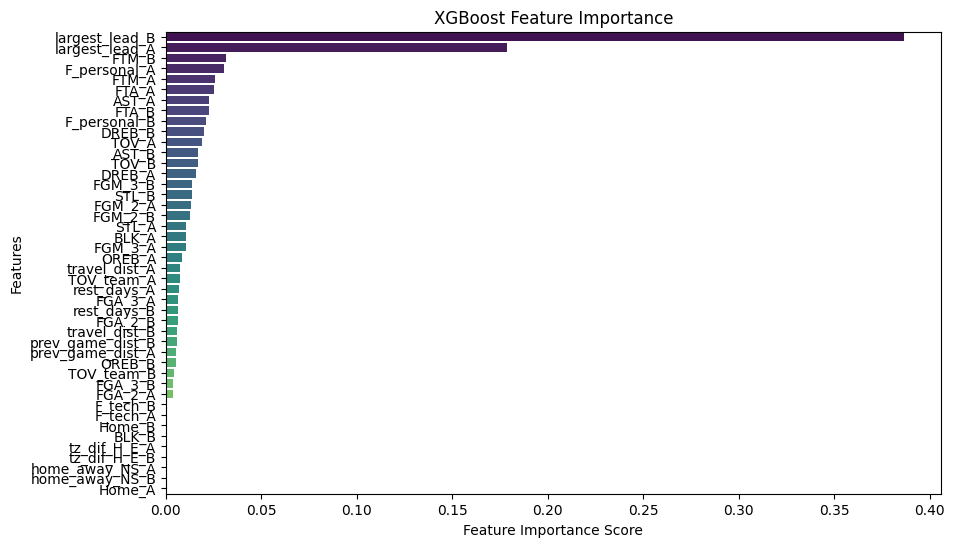

Win Probability:
air_force_falcons: 45.19% | utah_state_aggies: 54.81%


In [ ]:
# 📌 Install required libraries (Ensures the correct versions are installed)
!pip uninstall -y scikit-learn xgboost
!pip install --upgrade --no-cache-dir scikit-learn xgboost seaborn

# 📌 Import required libraries
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 📌 Mount Google Drive (Upload dataset to Google Drive first)
#from google.colab import drive
#drive.mount('/content/drive')

# 📌 Load dataset (Update the path to your actual file location)
file_path = "games_merged_corrected.csv"  # Change this to your actual file path
df = pd.read_csv(file_path)

# 📌 Check dataset structure
print(df.head())  # View first few rows
print(df.columns)  # Check column names

# 📌 Handle missing values
df.fillna(0, inplace=True)  # Replace NaNs with 0

# 📌 Create "Winner" column (1 if Team_A wins, 0 if Team_B wins)
df['Winner'] = np.where(df['Score_A'] > df['Score_B'], 1, 0)

# 📌 Select relevant features
features = [
    'Home_A', 'Home_B',
    'FGA_2_A', 'FGA_2_B', 'FGM_2_A', 'FGM_2_B',
    'FGA_3_A', 'FGA_3_B', 'FGM_3_A', 'FGM_3_B',
    'AST_A', 'AST_B', 'BLK_A', 'BLK_B', 'STL_A', 'STL_B',
    'TOV_A', 'TOV_B', 'FTA_A', 'FTA_B', 'FTM_A', 'FTM_B',
    'TOV_team_A', 'TOV_team_B', 'DREB_A', 'DREB_B', 'OREB_A', 'OREB_B',
    'F_tech_A', 'F_tech_B', 'F_personal_A', 'F_personal_B',
    'largest_lead_A', 'largest_lead_B', 'rest_days_A', 'rest_days_B',
    'tz_dif_H_E_A', 'tz_dif_H_E_B', 'prev_game_dist_A', 'prev_game_dist_B',
    'home_away_NS_A', 'home_away_NS_B', 'travel_dist_A', 'travel_dist_B'
]

X = df[features]  # Feature matrix
y = df['Winner']  # Target variable

# 📌 Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 📌 Define parameter distribution for Randomized Search
# ✅ Corrected parameter names by prefixing with 'model__'
param_dist = {
    'model__max_depth': [3, 5, 7, 9],
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__subsample': [0.6, 0.8, 1.0]
}

# 📌 Create a pipeline with StandardScaler (Fix for '__sklearn_tags__' error)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        use_label_encoder=False,
        tree_method="hist"  # ✅ Fix for '__sklearn_tags__' error
    ))
])

# 📌 Run RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    scoring='accuracy',
    cv=5,
    n_iter=10,
    random_state=42,
    n_jobs=-1
)

# 📌 Train the model
random_search.fit(X_train, y_train)

# 📌 Get best hyperparameters
best_params = random_search.best_params_
print(f"Best Parameters: {best_params}")

# 📌 Train the final model with best hyperparameters
best_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    tree_method="hist",  # ✅ Fix for '__sklearn_tags__' error
    max_depth=best_params['model__max_depth'],
    n_estimators=best_params['model__n_estimators'],
    learning_rate=best_params['model__learning_rate'],
    subsample=best_params['model__subsample']
)
best_model.fit(X_train, y_train)

# 📌 Evaluate accuracy
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
logloss = log_loss(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Model Accuracy: {accuracy:.2%}")
print(f"Log Loss: {logloss:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# 📌 Feature Importance Visualization
feature_importance = best_model.feature_importances_
importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importance_df['Importance'], y=importance_df['Feature'], palette='viridis')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")
plt.show()

# 📌 Function to Predict Win Probability for Two Teams
import numpy as np

def predict_winner(team_A, team_B, df, model):
    # Check if teams exist in the dataset
    '''if team_A not in df['Team_A'].values or team_B not in df['Team_B'].values:
        print(f"Error: One or both teams not found in dataset.")
        return'''

    # 📌 Compute average stats for Team A (excluding non-numeric columns)
    team_A_stats = df[df['Team_A'] == team_A].select_dtypes(include=[np.number]).mean()

    # 📌 Compute average stats for Team B (excluding non-numeric columns)
    team_B_stats = df[df['Team_B'] == team_B].select_dtypes(include=[np.number]).mean()

    # 📌 Create input row based on average stats
    input_data = pd.DataFrame({
        'Home_A': [0],  # Neutral venue assumption
        'Home_B': [0],
        'FGA_2_A': [team_A_stats['FGA_2_A']], 'FGA_2_B': [team_B_stats['FGA_2_B']],
        'FGM_2_A': [team_A_stats['FGM_2_A']], 'FGM_2_B': [team_B_stats['FGM_2_B']],
        'FGA_3_A': [team_A_stats['FGA_3_A']], 'FGA_3_B': [team_B_stats['FGA_3_B']],
        'FGM_3_A': [team_A_stats['FGM_3_A']], 'FGM_3_B': [team_B_stats['FGM_3_B']],
        'AST_A': [team_A_stats['AST_A']], 'AST_B': [team_B_stats['AST_B']],
        'BLK_A': [team_A_stats['BLK_A']], 'BLK_B': [team_B_stats['BLK_B']],
        'STL_A': [team_A_stats['STL_A']], 'STL_B': [team_B_stats['STL_B']],
        'TOV_A': [team_A_stats['TOV_A']], 'TOV_B': [team_B_stats['TOV_B']],
        'FTA_A': [team_A_stats['FTA_A']], 'FTA_B': [team_B_stats['FTA_B']],
        'FTM_A': [team_A_stats['FTM_A']], 'FTM_B': [team_B_stats['FTM_B']],
        'TOV_team_A': [team_A_stats['TOV_team_A']], 'TOV_team_B': [team_B_stats['TOV_team_B']],
        'DREB_A': [team_A_stats['DREB_A']], 'DREB_B': [team_B_stats['DREB_B']],
        'OREB_A': [team_A_stats['OREB_A']], 'OREB_B': [team_B_stats['OREB_B']],
        'F_tech_A': [team_A_stats['F_tech_A']], 'F_tech_B': [team_B_stats['F_tech_B']],
        'F_personal_A': [team_A_stats['F_personal_A']], 'F_personal_B': [team_B_stats['F_personal_B']],
        'largest_lead_A': [team_A_stats['largest_lead_A']], 'largest_lead_B': [team_B_stats['largest_lead_B']],
        'rest_days_A': [team_A_stats['rest_days_A']], 'rest_days_B': [team_B_stats['rest_days_B']],
        'tz_dif_H_E_A': [team_A_stats['tz_dif_H_E_A']], 'tz_dif_H_E_B': [team_B_stats['tz_dif_H_E_B']],
        'prev_game_dist_A': [team_A_stats['prev_game_dist_A']], 'prev_game_dist_B': [team_B_stats['prev_game_dist_B']],
        'home_away_NS_A': [team_A_stats['home_away_NS_A']], 'home_away_NS_B': [team_B_stats['home_away_NS_B']],
        'travel_dist_A': [team_A_stats['travel_dist_A']], 'travel_dist_B': [team_B_stats['travel_dist_B']]
    })

    # 📌 Predict win probability
    prob = model.predict_proba(input_data)[0][1]  # Probability of Team_A winning

    print(f"Win Probability:\n{team_A}: {prob:.2%} | {team_B}: {(1 - prob):.2%}")




# 📌 Example Usage:
team_A_name = "air_force_falcons"
team_B_name = "utah_state_aggies"
predict_winner(team_A_name, team_B_name, df, best_model)